# Chronos-Bolt layer probing - structural aliasing, lean edition

One signal, generated here (named + saved), pushed through every stage. Three questions:
1. **Irreversibility** - the one-patch-shift test: at an integer cpp `x[n+P]=x[n]`, so a signal and its
   one-patch-advanced copy are identical from `patched` on (incl. the decoder output) -> the loss is
   architectural and cannot be undone.
2. **Round-trip** - does the forecast reproduce the input spectrum?
3. **Where the injected tone vanishes** - output-vs-input frequency sweep (analog of Pagani et al. Fig. 5).

Note on the decoder: Chronos-Bolt is a *direct* multi-horizon forecaster - the decoder runs once on
learned query tokens and emits the whole horizon, it is NOT autoregressive. So its analysis is the
frequency response of its **output**, plus the shift distance read at `dec_out`.

## Setup

In [86]:
import torch, sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from chronos import BaseChronosPipeline
np.random.seed(42); torch.manual_seed(42)
import pandas as pd
import json
sys.path.insert(0, "../data/synthetic/")         
import signalGenerator as sg   
from pandas import json_normalize


pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-bolt-tiny", device_map="cpu")
model = pipeline.model; cfg = model.config.chronos_config
P, S_DEF, PRED_LEN = cfg["input_patch_size"], cfg["input_patch_stride"], cfg["prediction_length"]
N_ENC, N_DEC = len(model.encoder.block), len(model.decoder.block)
print(f"P={P} S={S_DEF} pred_len={PRED_LEN} enc={N_ENC} dec={N_DEC}")

P=16 S=16 pred_len=64 enc=4 dec=4


In [87]:
OUT = Path("../outputs/signals/")
existing = [d for d in OUT.iterdir() if d.is_dir() and d.name.startswith("signal_")]
if existing:
    i = max([int(d.name.split("_")[1]) for d in existing]) + 1
else:    
    i = 0
OUT = OUT/f"signal_{i}"
OUT.mkdir(parents=True, exist_ok=True)
print(f"Saving outputs to {OUT}")

Saving outputs to ../outputs/signals/signal_5


## 1 - Generate the probe signal here (named & saved)
Edit `GEN` and `INJECT`. cpp = cycles per patch (blind spots at integer cpp); or use mode `"hz"`
(cpp = value*P/fs). The signal is saved under `../outputs/signals/<name>.npy`.

In [88]:
json_config = [
    {
        "generator": "kernelsynth",
        "n_realizations": 5,
        "seed": 15,
        "params": {
            "J": 5,
            "l_syn": 512,
            "fs": 256,
            "jitter": 1e-4,
            "P": 16,
            "inject": {
                "mode": "cpp",
                "value": 4.0,
                "amplitude": 0.01,
                "phase": 0.0
            }
        }
    }
]

In [89]:
if json_config[0]["generator"] == "kernelsynth":
    gen = sg.runKernelSynth(json_config[0]["params"], json_config[0]["seed"], output_dir=OUT)
    NAME = "kernelsynth"
else:
    gen = sg.runTSMixup(json_config[0]["params"], json_config[0]["seed"], output_dir=OUT)
    NAME = "tsmixup"

print(gen.getParameters())

{'generator': 'KernelSynth', 'J': 5, 'l_syn': 512, 'fs': 256, 'jitter': 0.0001, 'inject': {'mode': 'cpp', 'value': 4.0, 'amplitude': 0.01, 'phase': 0.0}}


In [90]:
signal = np.asarray(gen.generate(), float).ravel()
gen.save(signal)
with open(OUT/"config.json", "w") as f:
    json.dump(json_config, f, indent=4)
    
ctx = signal[:512]

inject = json_config[0]["params"]["inject"]
INJECT = {
    "mode": inject["mode"],
    "value": inject["value"] if inject["mode"] == "cpp" else inject["value"] * P / 256,
    "amplitude": inject["amplitude"],
    "phase": inject["phase"]
}
FS = json_config[0]["params"]["fs"]

In [91]:
cpp = INJECT["value"] if INJECT["mode"] == "cpp" else INJECT["value"] * P / FS
cls = "BLIND (on grid)" if abs(cpp - round(cpp)) < 1e-6 and 1 <= round(cpp) <= P // 2 else "off-grid / safe"
print(f"saved {gen.path()}  |  cpp={cpp:.3f}  [{cls}]")

saved ../outputs/signals/signal_5/KernelSynth_J5_l_syn512_fs256_jitter0.0001__cpp4_amp0.01_ph0.txt  |  cpp=4.000  [BLIND (on grid)]


In [92]:
params = gen.getParameters()

df = json_normalize(
    params,
    sep="_"
)

df

,generator,J,l_syn,fs,jitter,inject_mode,inject_value,inject_amplitude,inject_phase
0,KernelSynth,5,512,256,0.0001,cpp,4.0,0.01,0.0


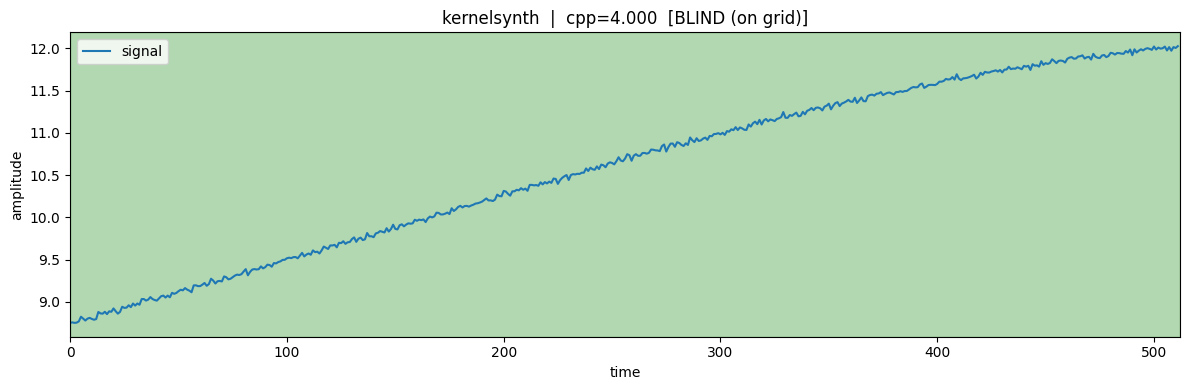

In [93]:
plt.figure(figsize=(12, 4))
plt.plot(signal, label="signal")
plt.axvspan(0, 512, color="green", alpha=0.3)
plt.title(f"{NAME}  |  cpp={cpp:.3f}  [{cls}]")
plt.xlabel("time"); plt.ylabel("amplitude"); plt.legend();
plt.xlim(0, len(signal));
plt.tight_layout(); plt.savefig(OUT/f"{NAME}.png") 
plt.show() 

## 2 - Capture every stage

In [94]:
def cut(x, P, S): return np.stack([x[i:i+P] for i in range(0, len(x)-P+1, S)])
def as_matrix(t):
    if isinstance(t, tuple): t = t[0]
    a = t.detach().cpu().numpy(); return a[0] if a.ndim == 3 else a

def forward_capture(context, stride=S_DEF):
    cap, handles = {}, []
    model.patch.patch_stride = stride
    def save(key, use_in=False):
        def hook(m, i, o): cap[key] = as_matrix(i[0] if use_in else o)
        return hook
    if hasattr(model, "instance_norm"): handles.append(model.instance_norm.register_forward_hook(save("scaled")))
    handles.append(model.patch.register_forward_hook(save("patched")))
    handles.append(model.input_patch_embedding.register_forward_hook(save("pre_embed", True)))
    handles.append(model.input_patch_embedding.register_forward_hook(save("post_embed")))
    for k, b in enumerate(model.encoder.block): handles.append(b.register_forward_hook(save(f"enc{k}")))
    for k, b in enumerate(model.decoder.block): handles.append(b.register_forward_hook(save(f"dec{k}")))
    if hasattr(model, "output_patch_embedding"): handles.append(model.output_patch_embedding.register_forward_hook(save("dec_out", True)))
    x = torch.tensor(np.asarray(context, np.float32)).unsqueeze(0)
    with torch.no_grad(): fc = pipeline.predict(x, prediction_length=PRED_LEN)
    for h in handles: h.remove()
    model.patch.patch_stride = S_DEF
    sc = cap.pop("scaled", None)
    cap = {"input": cut(context, P, stride),
           "scaled": cut(np.asarray(sc).ravel(), P, stride) if sc is not None else cut(context, P, stride), **cap}
    return fc, cap

forecast, cap = forward_capture(ctx)
STAGES = ["input","scaled","patched","pre_embed","post_embed",
          *[f"enc{k}" for k in range(N_ENC)], *[f"dec{k}" for k in range(N_DEC)], "dec_out"]
STAGES = [s for s in STAGES if s in cap]
print("captured:", len(STAGES), "stages")

captured: 14 stages


## 3 - Relevance detector for THIS signal (leakage-free, single example)

Only the signal generated in Section 1 - no sweep, no other cpp, no comparison. The generator builds
`signal = normalised_background + amp*sin(injected)`, so subtracting the known injected tone recovers
**this signal's own background**. The detector is then one curve: how much the injected component
perturbs each stage's representation, with the tone-off background as a matched control:

`relevance_s = || h_s(signal) - h_s(background) ||  /  || h_s(background) ||`

High = the component is still imprinted at stage `s`; a drop = the model starts representing `signal`
and its background alike, i.e. the injected component is being eaten there. No labels -> no leakage.

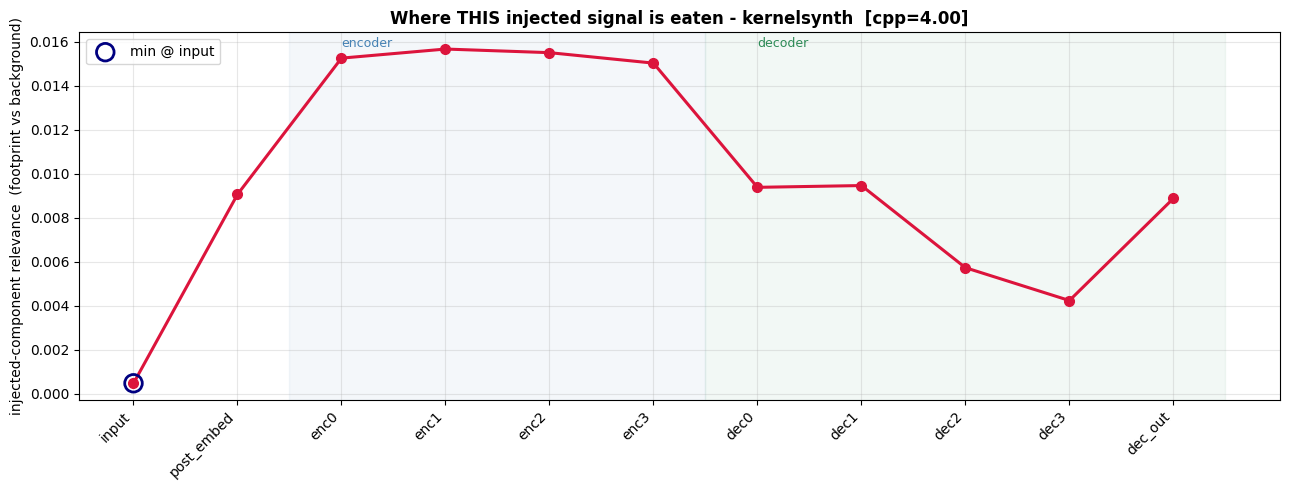

relevance per stage: {'input': 0.0, 'post_embed': 0.009, 'enc0': 0.015, 'enc1': 0.016, 'enc2': 0.015, 'enc3': 0.015, 'dec0': 0.009, 'dec1': 0.009, 'dec2': 0.006, 'dec3': 0.004, 'dec_out': 0.009}
weakest stage: input (0.000);  dec_out: 0.009


In [95]:
def stage_dist(a, b):
    m = min(len(a), len(b)); a, b = np.asarray(a[:m], float), np.asarray(b[:m], float)
    return float(np.abs(a-b).mean() / (np.abs(b).mean() + 1e-9))

# recover THIS signal's own background by subtracting its injected tone
spec = json_config[0]["params"]["inject"]
amp_ = float(spec.get("amplitude", 1.0)); ph_ = float(spec.get("phase", 0.0))
n = np.arange(len(signal))
if spec["mode"] == "cpp":
    tone = amp_ * np.sin(2*np.pi*float(spec["value"])*n/P + ph_)
else:  # hz
    fs_ = float(json_config[0]["params"].get("fs", 256))
    tone = amp_ * np.sin(2*np.pi*float(spec["value"])*(n/fs_) + ph_)
background = signal - tone

_, cap_bg = forward_capture(background[:512])             # matched control (tone off)

REL_STAGES = ["input", "post_embed", *[f"enc{k}" for k in range(N_ENC)],
              *[f"dec{k}" for k in range(N_DEC)], "dec_out"]
REL_STAGES = [s for s in REL_STAGES if s in cap and s in cap_bg]
rel = [stage_dist(cap[s], cap_bg[s]) for s in REL_STAGES]   # cap = THIS signal (from Section 2)

xs = np.arange(len(REL_STAGES)); jmin = int(np.argmin(rel))
fig, ax = plt.subplots(figsize=(13, 5))
enc0, dec0 = REL_STAGES.index("enc0"), REL_STAGES.index("dec0")
ax.axvspan(enc0-0.5, dec0-0.5, color="steelblue", alpha=.06)
ax.axvspan(dec0-0.5, len(REL_STAGES)-0.5, color="seagreen", alpha=.06)
ax.plot(xs, rel, "o-", color="crimson", lw=2.2, ms=7)
ax.scatter([jmin], [rel[jmin]], s=160, facecolors="none", edgecolors="navy", lw=2,
           zorder=5, label=f"min @ {REL_STAGES[jmin]}")
ax.set_xticks(xs); ax.set_xticklabels(REL_STAGES, rotation=45, ha="right")
ax.set_ylabel("injected-component relevance  (footprint vs background)")
ax.set_title(f"Where THIS injected signal is eaten - {NAME if 'NAME' in dir() else gen.path().name}  "
             f"[cpp={cpp:.2f}]", fontweight="bold")
ax.text(enc0, ax.get_ylim()[1]*0.96, "encoder", color="steelblue", fontsize=9)
ax.text(dec0, ax.get_ylim()[1]*0.96, "decoder", color="seagreen", fontsize=9)
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT/"L1_relevance_detector.png", dpi=140, bbox_inches="tight"); plt.show()
print("relevance per stage:", {s: round(r, 3) for s, r in zip(REL_STAGES, rel)})
print(f"weakest stage: {REL_STAGES[jmin]} ({rel[jmin]:.3f});  dec_out: {rel[-1]:.3f}")

## 4 - Round-trip: input vs forecast spectrum

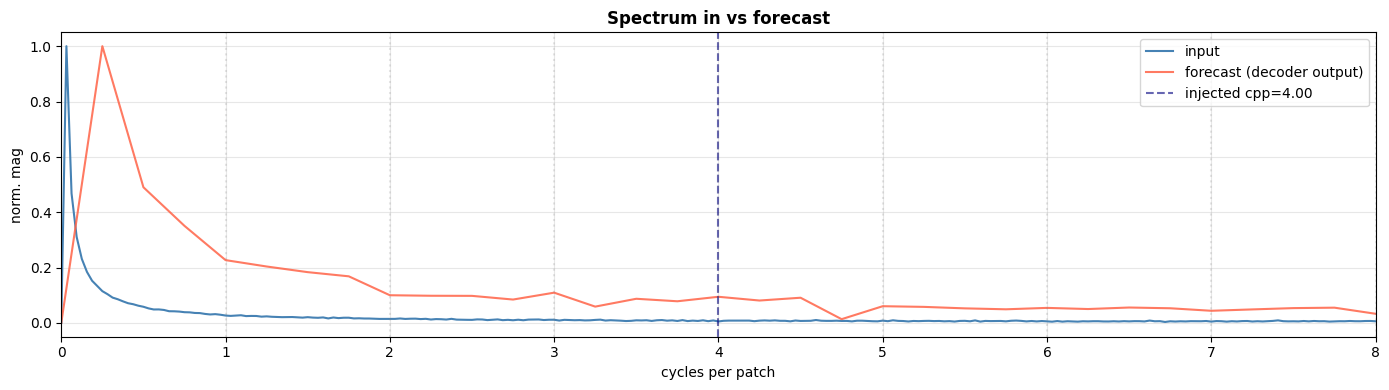

In [96]:
pred = forecast[0].median(dim=0).values.numpy()
def spec(x):
    x = np.asarray(x, float)-np.mean(x); m = np.abs(np.fft.rfft(x)); return np.fft.rfftfreq(len(x))*P, m
cin, mi = spec(ctx); cout, mo = spec(pred)
plt.figure(figsize=(14, 4))
plt.plot(cin, mi/(mi.max()+1e-9), color="steelblue", label="input")
plt.plot(cout, mo/(mo.max()+1e-9), color="tomato", alpha=.85, label="forecast (decoder output)")
plt.axvline(cpp, color="navy", ls="--", alpha=.6, label=f"injected cpp={cpp:.2f}")
for k in range(1, P//2+1): plt.axvline(k, color="grey", ls=":", alpha=.2)
plt.xlim(0, P/2); plt.xlabel("cycles per patch"); plt.ylabel("norm. mag")
plt.title("Spectrum in vs forecast", fontweight="bold"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT/"L1_roundtrip.png", dpi=140, bbox_inches="tight"); plt.show()

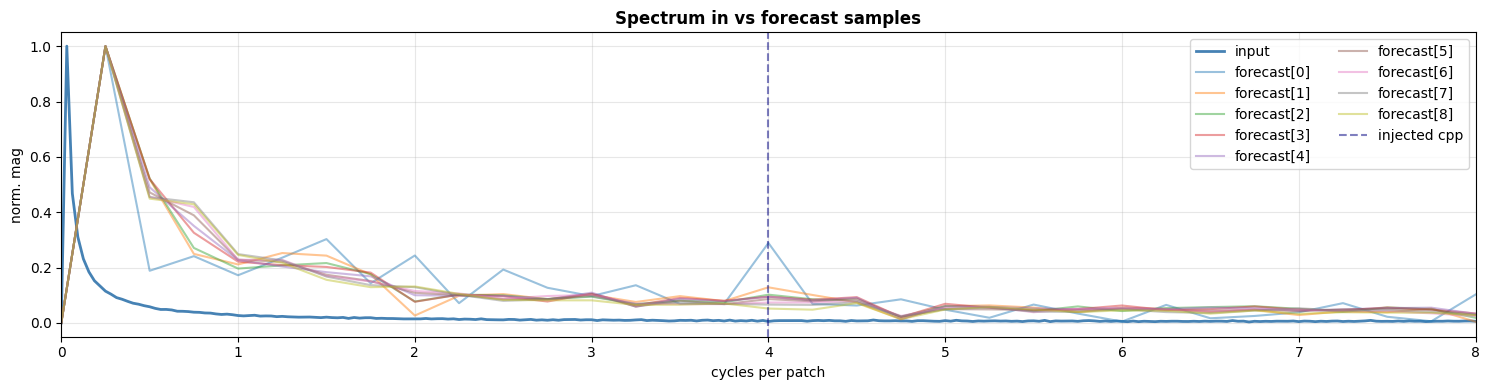

In [97]:
preds = [forecast[0][i].numpy() for i in range(9)]

def spec(x):
    x = np.asarray(x, float) - np.mean(x)
    m = np.abs(np.fft.rfft(x))
    return np.fft.rfftfreq(len(x)) * P, m

cin, mi = spec(ctx)

plt.figure(figsize=(15, 4))
plt.plot(cin, mi / (mi.max() + 1e-9), color="steelblue", lw=2, label="input")

for i, pred in enumerate(preds):
    cout, mo = spec(pred)
    plt.plot(cout, mo / (mo.max() + 1e-9), alpha=0.45, label=f"forecast[{i}]")

if cpp:
    plt.axvline(cpp, color="navy", ls="--", alpha=0.5, label="injected cpp")

plt.xlim(0, P / 2)
plt.xlabel("cycles per patch")
plt.ylabel("norm. mag")
plt.title("Spectrum in vs forecast samples", fontweight="bold")
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "L1_roundtrip_samples.png", dpi=140, bbox_inches="tight")
plt.show()




In [98]:
print("pred std:", np.std(pred))
print("pred min:", pred.min())
print("pred max:", pred.max())
print("pred first values:", pred[:20])

pred std: 0.06173338
pred min: 12.079541
pred max: 12.293112
pred first values: [12.121101  12.101049  12.089623  12.080509  12.085215  12.085043
 12.079541  12.08314   12.091384  12.091253  12.090859  12.095079
 12.106661  12.1235895 12.1258335 12.110481  12.109256  12.118474
 12.113517  12.104995 ]
